/tmp/ipykernel_3954/867995523.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[0, 0], palette='pastel')


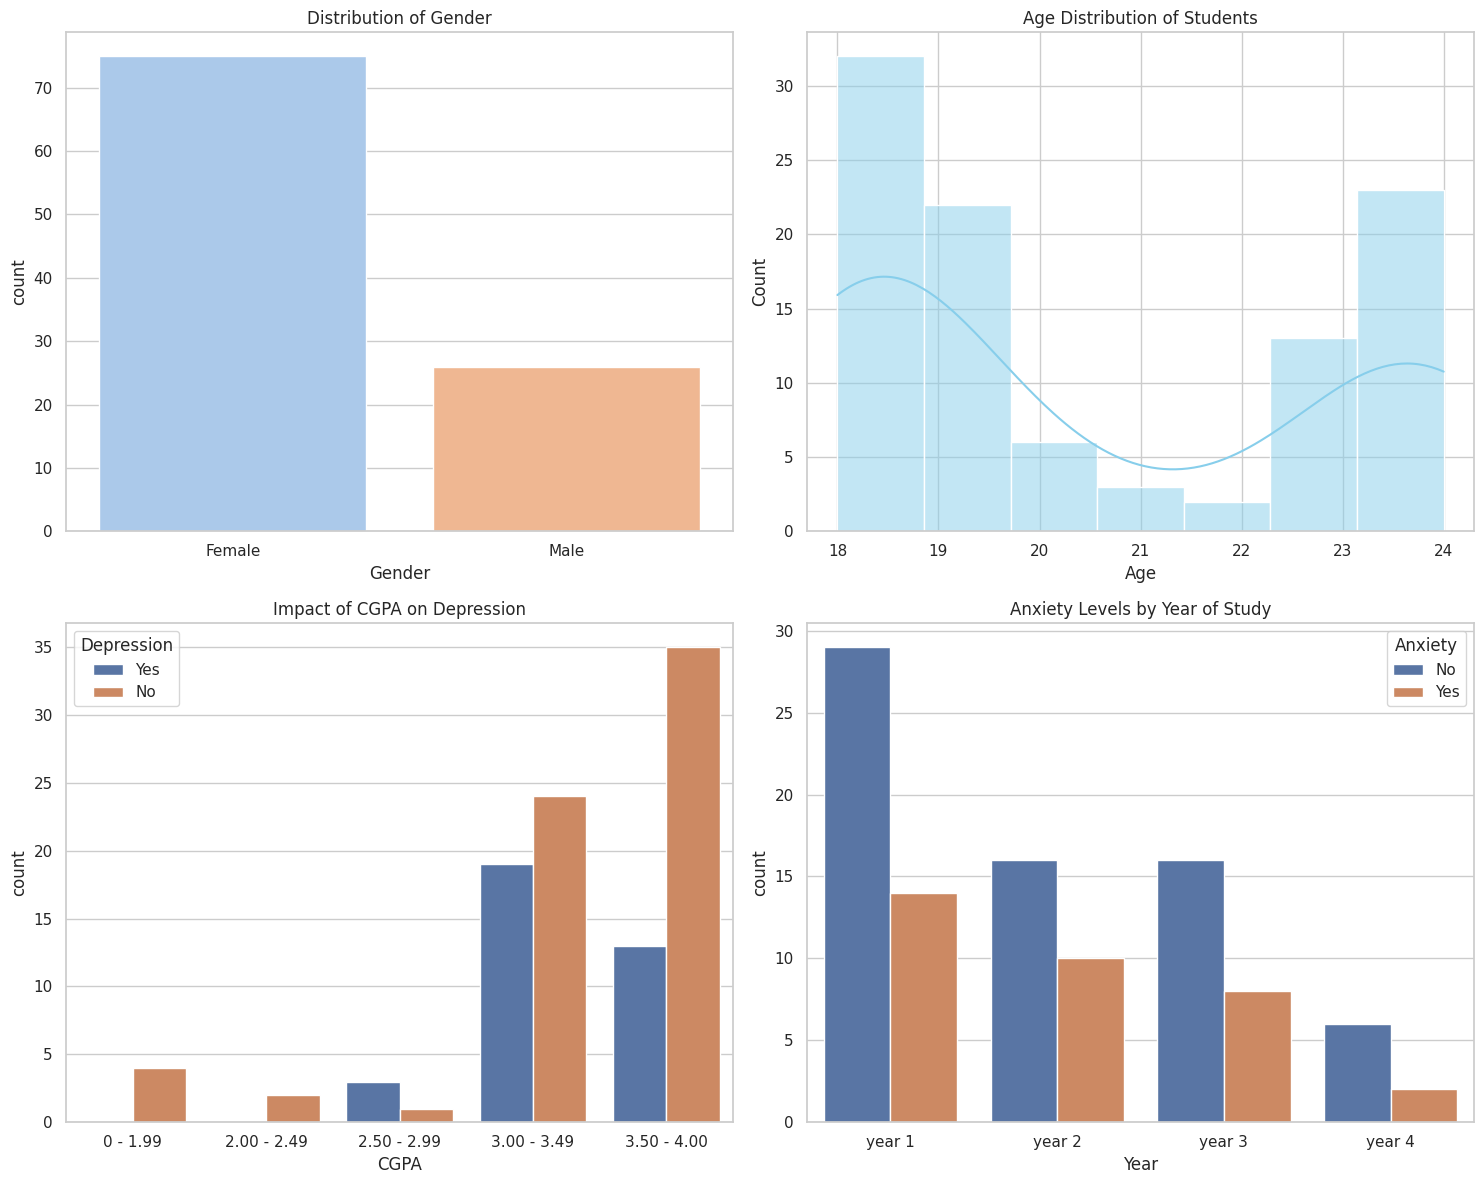

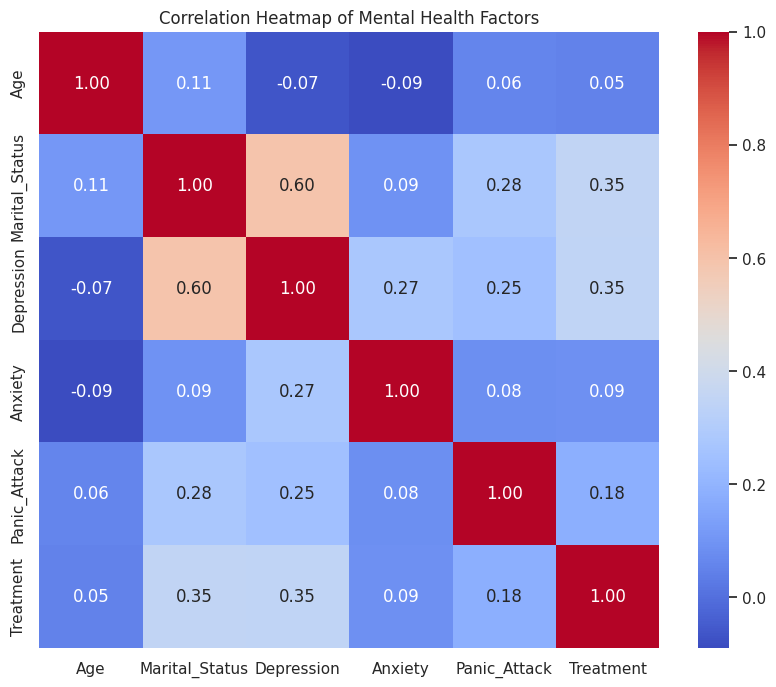

Top 5 Courses with Highest Depression counts:
Course
engineering    7
bit            5
bcs            5
psychology     2
benl           2
Name: count, dtype: int64

Percentage of Students Seeking Treatment:
Treatment
No     94.059406
Yes     5.940594
Name: proportion, dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Student Mental health.csv')
df.columns = ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status',
              'Depression', 'Anxiety', 'Panic_Attack', 'Treatment']
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Year'] = df['Year'].str.strip().str.lower()
df['Course'] = df['Course'].str.strip().str.lower()
df['CGPA'] = df['CGPA'].str.strip()
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.countplot(data=df, x='Gender', ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Distribution of Gender')
sns.histplot(df['Age'], bins=7, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Age Distribution of Students')
sns.countplot(data=df, x='CGPA', hue='Depression', ax=axes[1, 0],
              order=sorted(df['CGPA'].unique()))
axes[1, 0].set_title('Impact of CGPA on Depression')
sns.countplot(data=df, x='Year', hue='Anxiety', ax=axes[1, 1],
              order=['year 1', 'year 2', 'year 3', 'year 4'])
axes[1, 1].set_title('Anxiety Levels by Year of Study')
plt.tight_layout()
plt.show()
binary_cols = ['Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Treatment']
df_numeric = df.copy()
for col in binary_cols:
    df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(10, 8))
corr = df_numeric[['Age', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Treatment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Mental Health Factors')
plt.show()
print("Top 5 Courses with Highest Depression counts:")
print(df[df['Depression'] == 'Yes']['Course'].value_counts().head(5))
print("\nPercentage of Students Seeking Treatment:")
print(df['Treatment'].value_counts(normalize=True) * 100)